In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.mock_maker import MakeMock

from source_code.likelihood import LSSlike

from cobaya.run import run

from copy import deepcopy

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c',

yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

# Settings

## Options

In [2]:
mock_path   = 'mock_data/new_LSS_GW_ellcut_LCDM'
camb_path   = '/home/Matteo/Codes/GW-MGCAMB'
observables = ['GC','WL','GWC','GWWL']


bin_to_plot = [1,3,6]

covmats_ells_toplot = [5,-1]

#We will run a grid chi2 test on this parameter
test_parameter = {'name': 'logA',
                  'variation': 0.1,
                  'latex': r'$\log{10^{10}A_s}$',
                  'Ngrid': 10}

## Specifications

In [3]:
gwspecs  = {'Nbins_GW': 6,
            'N_gw': int(1.e6),
            'sigma_eps_gw': 0.01,
            'fsky': 0.35,
            'scale_cut': {'method': 'ell_cut', 'value': 200}}

# Fiducial

In [4]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.002918,
            'a4': -0.0006784,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            #'tau': 0.05,
            #'w': -1.,
            #'wa': 0.,
            #'mnu': 0.06,
            #MG params
            'mu0': 0.,
            'sigma0': 0.,
            'MG_flag': 1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

# Running mock maker

In [5]:
mock = MakeMock(gwspecs,observables,camb_path,fiducial,test_parameter)


Computing fiducial observables...
...done in 63.77 s


In [6]:
print(mock.mock_data.keys())

dict_keys(['noiseless', 'noisy', 'covmat_dict', 'distributions'])


# Showcase mock products

## Extracting noise from covariance diagonal (approximated)

In [7]:
error_df = pd.DataFrame({'ells': mock.fiducial_obs['ells']})
for obs1 in mock.fishmodule.renamed_obs:
    for obs2 in mock.fishmodule.renamed_obs:
        if obs1+obs2 not in ['LG','WCG','WCL','WLG','WLL','WLWC']:
            for bi in bin_to_plot:
                error = []
                for ell in mock.fiducial_obs['ells']:
                    ellcov = mock.mock_data['covmat_dict'][str(ell)]
                    error.append(np.sqrt(ellcov.at[obs1+str(bi)+'x'+obs2+str(bi),obs1+str(bi)+'x'+obs2+str(bi)]))
    
                error_df[obs1+str(bi)+'x'+obs2+str(bi)] = error

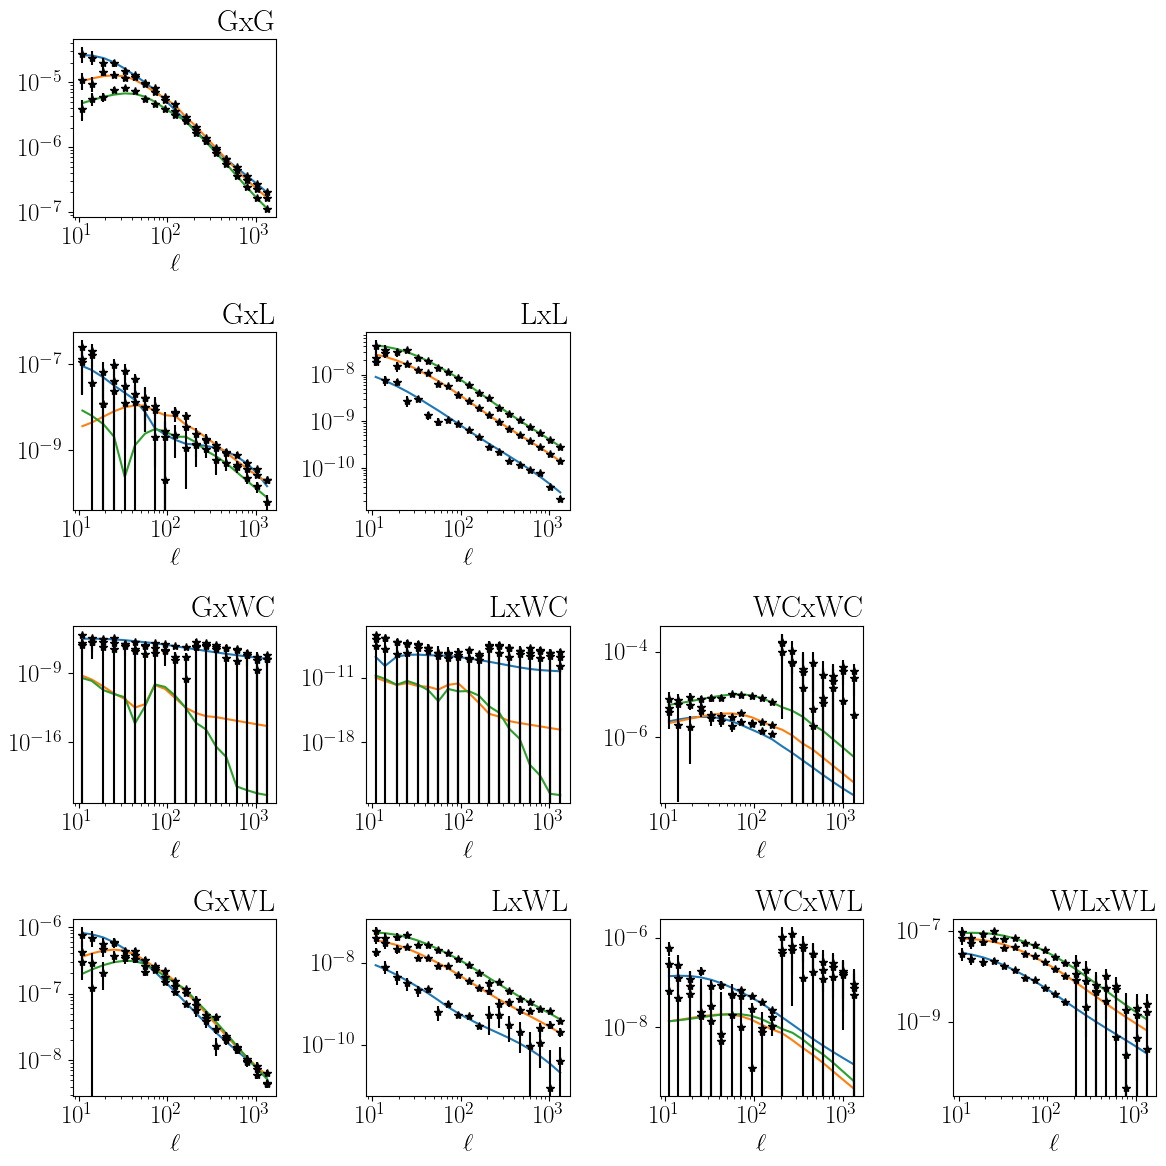

In [8]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(mock.fishmodule.renamed_obs),
                              nrows=len(mock.fishmodule.renamed_obs))
if len(mock.fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(mock.fishmodule.renamed_obs):
    for i,obs2 in enumerate(mock.fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:

            df = pd.melt(mock.mock_data['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                        for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)
#
            for bi in bin_to_plot:
                axes[i,j].errorbar(mock.mock_data['noisy']['ells'],abs(mock.mock_data['noisy'][obs1+str(bi)+'x'+obs2+str(bi)]),
                                  yerr=error_df[obs1+str(bi)+'x'+obs2+str(bi)],
                                  marker='*',ls='',color='black')

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            if obs1+obs2 != 'GL':
                axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

## Saving mock to file

In [9]:
if mock_path != '':
    mock.mock_data['noiseless'].to_csv(mock_path+'_Cls_noiseless.dat',sep='\t',header=True)
    mock.mock_data['noisy'].to_csv(mock_path+'_Cls_noisy.dat',sep='\t',header=True)
    np.save(mock_path+'_covmat.npy',mock.mock_data['covmat_dict'])
    np.save(mock_path+'_source_distribution.npy',mock.mock_data['distributions'])

## Mock properties

In [10]:
# SNR check to be added here

# Mock testing

In [11]:
stop = true

NameError: name 'true' is not defined

In [ ]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(test.fishmodule.renamed_obs),
                              nrows=len(test.fishmodule.renamed_obs))
if len(mock.fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(mock.fishmodule.renamed_obs):
    for i,obs2 in enumerate(mock.fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            #df = pd.melt(mock.fiducial_obs.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) for bi in bin_to_plot],
            #             value_name='value',var_name='Bin')
            #sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            df = pd.melt(test.mock_data['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                        for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            #df = pd.melt(full_noise,id_vars=['ells'],value_vars=[obs1+str(i)+'x'+obs2+str(i) for i in bin_to_plot],
            #                 value_name='value',var_name='Bin')
            #sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0,linestyle=':')
#
            for bi in bin_to_plot:
                axes[i,j].errorbar(test.mock_data['noisy']['ells'],abs(test.mock_data['noisy'][obs1+str(bi)+'x'+obs2+str(bi)]),
                                  yerr=error_df[obs1+str(bi)+'x'+obs2+str(bi)],
                                  marker='*',ls='',color='black')

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            if obs1+obs2 != 'GL':
                axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

In [ ]:
chi2 = []
for ind,ell in enumerate(test.fiducial_obs['ells']):
    diffvec = test.mock_data['noiseless'].iloc[ind][test.all_cols].values-test.mock_data['noisy'].iloc[ind][test.all_cols].values
    chi2.append(np.dot(diffvec,np.dot(np.linalg.inv(test.mock_data['covmat_dict'][str(ell)]),diffvec))/len(test.all_cols))

plt.figure()
plt.plot(test.fiducial_obs['ells'],chi2)
plt.axhline(y=1,ls=':',color='black')
plt.xscale('log')
plt.yscale('log');

In [ ]:
from bios import read

myfid = deepcopy(test.fiducial)
del myfid['tau']
del myfid['w']
del myfid['wa']
del myfid['mnu']

baseline = read('settings/LCDM_3x2pt_full_nautilus.yaml')
del baseline['output']
baseline['likelihood']['LSS']['external']  = LSSlike
baseline['likelihood']['LSS']['data_path'] = mock_path

eval_dict = {}
for par,val in myfid.items():
    if par not in baseline['params']:
        baseline['params'][par] = val
    else:
        eval_dict[par] = val

In [ ]:
baseline['sampler'] = {'evaluate': {'override': eval_dict}}
updated_info,sampler = run(baseline)

In [ ]:
Ndof = len(test.all_cols)*len(test.fiducial_obs['ells'])
print(Ndof)

In [ ]:
baseline['likelihood']['LSS']['use_noiseless_cls'] = False
updated_info,sampler = run(baseline)